# Trabajo Práctico 1 | Aplicaciones Computacionales en Negocios
### Ledesma, Benjamín - Luna, Candelaria - Mendez, Agustín - Pizi Restaine, Lucía

---

### Presentación del problema

El Aeroparque Jorge Newbery (AEP) recibe diariamente un gran volumen de vuelos, lo que hace que su operación sea sensible a dos factores clave: la congestión aérea en horarios pico y las condiciones climáticas adversas.

Estos factores introducen incertidumbre en el proceso de aproximación y aterrizaje, generando riesgo de demoras, saturación del servicio y posibles desvíos a aeropuertos alternativos como el de Montevideo.

El objetivo de este trabajo es modelar y simular el comportamiento de los arribos a AEP bajo diferentes escenarios de demanda y condiciones imprevistas. Para ello, se busca:

- Analizar el desempeño del sistema en distintos niveles de demanda (λ).  
- Estudiar las consecuencias de interrupciones y cierres sorpresivos.  
- Medir indicadores de performance como atrasos, congestión y desvíos.  
- Proponer políticas que mejoren la operación del sistema.  

---

### Modelado del sistema

Para representar el proceso de arribo y aterrizaje, se tuvieron en cuenta las siguientes simplificaciones y supuestos:

- El horario de operación es de 6:00 am a 00:00.  
- Cada avión comienza su aproximación al aparecer en el radar a 100 millas náuticas (mn).  
- La velocidad del avión se ajusta según su distancia a la pista y la separación con el avión de adelante.  
- Se requiere una distancia mínima de 4 minutos entre aviones consecutivos.  
- Si la velocidad cae por debajo del mínimo permitido en el rango de distancia, el avión debe salirse de la fila. En ese caso:
    - Intenta reinsertarse si encuentra un gap de al menos 10 minutos.  
    - Si no es posible, se desvía a Montevideo.  

Además, se contemplan eventos especiales:  
- Cambios en la tasa de arribos (λ).  
- Interrupciones puntuales en las aproximaciones.  
- Tormentas o cierres sorpresivos de AEP.  

El sistema se simula minuto a minuto, permitiendo capturar dinámicas realistas de congestión y atraso.


---

### Ejercicio 1

Importamos librerías:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import seaborn as sns
from math import exp, factorial

# Definimos una seed para asegurar replicabilidad
SEED = 2509

Definimos parámetros del modelo:

In [2]:
# Distancias y velocidades según la aproximación
distancias_mn = [100, 50, 15, 5, 0]  # millas náuticas a AEP
vel_min = [300, 250, 200, 150, 120]  # nudos mínimos permitidos
vel_max = [500, 300, 250, 200, 150]  # nudos máximos permitidos

# Conversión
MN_A_KM = 1.852
NUDOS_A_KMH = 1.852

# Restricciones
separacion_min = 4  # separación mínima entre aterrizajes
gap_reentrada = 10  # min necesarios para reinsertarse en la cola

# Tiempo de simulación (6am a medianoche)
t_total_min = (24 - 6) * 60  # 1080 minutos

La probabilidad de arribo por minuto se define a partir de datos reales.  

En promedio, Aeroparque recibe alrededor de 350 vuelos diarios.  

Como en nuestro modelo el aeropuerto funciona de 6:00 a 00:00 (18 horas), ajustamos:

- Vuelos por hora: 350 / 24 ≈ 14,6  
- Vuelos en 18 horas: 14,6 × 18 ≈ 270  
- Probabilidad de arribo por minuto: 270 / 1080 ≈ 15 / 60

Este valor de λ = 15/60 representa el máximo posible, ya que la restricción de seguridad impide aterrizajes con menos de 4 minutos de separación.  

In [3]:
# Probabilidad de llegada por minuto
lam = 15 / 60

Definimos una clase avión:

Cada avión se modela individualmente, con estados como “en vuelo”, “aterrizado”, “desviado” o “interrumpido”. 

A su vez consideramos otros atributos importantes como la velocidad, minuto de aparición en el radar, de aterrizaje, si está en la cola, etc.

In [4]:
class Avion:
    def __init__(self, t_llegada, idx):
        # Representa un avión en aproximación a AEP
        self.id = idx                   # número de identificación del avión
        self.t_llegada = t_llegada      # minuto en que aparece en radar
        self.distancia = 100            # millas náuticas iniciales
        self.velocidad = 500            # nudos inciales
        self.estado = 'en_vuelo'        # estados posibles: en_vuelo, aterrizado, montevideo, desviado, interrumpido
        self.t_aterrizaje = None        # minutos de aterrizaje efectivo
        self.encolado = False           # si está en la cola de aproximación
        self.atraso = 0                 # atraso del avión
        self.velocidadReducida = False  # esta reduciendo la velocidad

    def actualizar_velocidad(self):
        # Ajusta la velocidad según la distancia a AEP
        if self.distancia > 100:
            self.velocidad = vel_max[0]
        elif self.distancia > 50:
            self.velocidad = vel_max[1]
        elif self.distancia > 15:
            self.velocidad = vel_max[2]
        elif self.distancia > 5:
            self.velocidad = vel_max[3]
        else:
            self.velocidad = vel_max[4]
    
    def setVelocidadMinima(self):
        # Ajusta la velocidad mínima según la distancia a AEP
        if self.distancia > 100:
            self.velocidad = vel_min[0]
        elif self.distancia > 50:
            self.velocidad = vel_min[1]
        elif self.distancia > 15:
            self.velocidad = vel_min[2]
        elif self.distancia > 5:
            self.velocidad = vel_min[3]
        else:
            self.velocidad = vel_min[4]

    def verificar_desvio(self):
        # Verifica si el avión debe desviarse por ir demasiado lento según la distancia
        # Devuelve True si debe desviar
        if self.distancia > 100:
            if self.velocidad < vel_min[0]:
                return True
        elif self.distancia > 50:
            if self.velocidad < vel_min[1]:
                return True
        elif self.distancia > 15:
            if self.velocidad < vel_min[2]:
                return True
        elif self.distancia > 5:
            if self.velocidad < vel_min[3]:
                return True
        else:
            if self.velocidad < vel_min[4]:
                return True
        return False

    def avanzar(self):
        # Avanza el avión 1 minuto según su velocidad actual
        self.distancia -= self.velocidad / 60  # nudos = mn/hora
        if self.distancia <= 0:
            self.distancia = 0
            self.estado = 'aterrizado'

Funciones auxiliares con el fin de utilizarlas durante las distintas simulaciones:

In [5]:
def generar_arribos(t_total, lam):
    # Genera un arreglo de minutos en los que aparece un avión en radar
    # En cada minuto la probabilidad de que llegue un avión es 'lam'
    arribos = []
    for t in range(t_total):
        if np.random.rand() < lam:
            arribos.append(t)
    return arribos

def estan_cerca_n_min(avion1, avion2, n):
    # Verifica si avion1 está a menos de n minutos de avion2
    return (avion2 != None) and ((avion1.distancia - avion2.distancia) / (avion2.velocidad / 60) < n and avion1.distancia > avion2.distancia)

def estan_cerca(avion1, avion2):
    # Verifica si avion1 está demasiado cerca de avion2 (4 minutos)
    return estan_cerca_n_min(avion1, avion2, 4)

def estan_muy_cerca(avion1, avion2):
    # Verifica si avion1 está muy cerca de avion2 (2 minutos)
    return estan_cerca_n_min(avion1, avion2, 2)

def estan_a_mas_de_cinco(avion1, avion2):
    return not estan_cerca_n_min(avion1, avion2, 5)

def encontrar_avion_adelante(cola, avion):
    # Devuelve el avión que está adelante del actual en la cola
    for i in range(1, len(cola)):
        if(cola[i].id == avion.id):
            return cola[i-1]
    return None

def getPosicionGap(avion, cola):
    # Encuentra un gap en la cola donde un avión desviado puede reinsertarse
    for i in range(len(cola)-1):
        if ( ((cola[i].distancia - cola[i+1].distancia) / (cola[i+1].velocidad / 60)) > 10 and (cola[i].distancia < avion.distancia and cola[i+1].distancia > avion.distancia)):
            return i+1
    if len(cola) == 0 or (len(cola) > 0 and ((100 - cola[-1].distancia) / (cola[-1].velocidad / 60) > 5 and cola[-1].distancia < avion.distancia)):
        return len(cola)
    return None

def calcular_t_ideal(avion):
    # Calcula el tiempo de aterrizaje ideal si el avión nunca redujera velocidad
    distancias = [100, 50, 15, 5, 0]
    vel_maxima = [300, 250, 200, 150]   # nudos
    tiempo_total = 0
    distancia_actual = avion.distancia  # inicia en 100 mn

    for i in range(len(distancias)-1):
        if distancia_actual > distancias[i+1]:
            tramo = distancia_actual - distancias[i+1]
            tiempo_total += tramo / (vel_maxima[i]/60)  # nudos a mn/min
            distancia_actual = distancias[i+1]

    return np.round(avion.t_llegada + tiempo_total)

Funciones para graficar y animar simulaciones:

In [6]:
def updateFrame(frame, num_planes, posiciones, scat, colors, history, trail_lines, trail_length):
    # Actualiza la animación para cada frame (minuto)
    xs, ys, cs = [], [], []

    for i in range(num_planes):
        pos = posiciones.loc[frame, i]

        if pos is not None:
            xs.append(frame)
            ys.append(pos)
            cs.append(colors[i])

            # Actualizar historial
            history[i].append((frame, pos))
            if len(history[i]) > trail_length:
                history[i].pop(0)

            # Actualizar línea de rastro
            hx, hy = zip(*history[i])
            trail_lines[i].set_data(hx, hy)
        else:
            # Avión aterrizado: limpiar historial y línea
            history[i] = []
            trail_lines[i].set_data([], [])

    scat.set_offsets(list(zip(xs, ys)))
    scat.set_color(cs)
    return [scat] + trail_lines

def graficarAnimado(nombre_archivo, posiciones, acciones, tieneTormenta=False, tiempoTormenta=0):
    num_planes = len(posiciones.columns)
    colors = ["#20B2AA" if i % 2 == 0 else "#17736E" for i in range(num_planes)]
    trail_length = 5   # acotado para que se vea mejor

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.set_xlim(0, t_total_min)
    ax.set_ylim(0, 110)
    ax.set_xlabel("Minuto del día")
    ax.set_ylabel("Distancia a AEP (mn)")
    ax.set_title("Posición de aviones en el tiempo (GIF)")
    ax.axhline(100, color='red', linestyle='--', label='Radar AEP')
    if(tieneTormenta):
        ax.axvline(tiempoTormenta, color='blue', linestyle='--', label='Inicio Tormenta')
        if tiempoTormenta + 30 <= t_total_min:
            ax.axvline(tiempoTormenta + 30, color='blue', linestyle='--', label='Fin Tormenta')
        else:
            ax.axvline(t_total_min, color='blue', linestyle='--', label='Fin Tormenta')

    scat = ax.scatter([], [], s=30)
    history = [[] for _ in range(num_planes)]
    trail_lines = [ax.plot([], [], color=colors[i], lw=2, alpha=0.7)[0] for i in range(num_planes)]
    eventos_artistas = []

    marcador_acciones = {
        "desvio": dict(marker="o", color="red", s=15),
        "desvio_montevideo": dict(marker="x", color="red", s=50, lw=2),
        "aterrizaje": dict(marker="P", color="green", s=60),  # tilde verde (P = pentágono)
        "interrupcion": dict(marker="x", color="red", s=60, lw=2),
    }

    def update(frame):
        x = [frame] * num_planes
        y = [posiciones.iloc[frame, i] for i in range(num_planes)]
        scat.set_offsets(list(zip(x, y)))
        scat.set_color(colors)

        for i in range(num_planes):
            history[i].append((frame, posiciones.iloc[frame, i]))
            if len(history[i]) > trail_length:
                history[i].pop(0)
            hx, hy = zip(*history[i])
            trail_lines[i].set_data(hx, hy)

        for i in range(num_planes):
            accion = acciones.iloc[frame, i]
            if accion in marcador_acciones:
                props = marcador_acciones[accion]
                artista = ax.scatter(frame, posiciones.iloc[frame, i], **props)
                eventos_artistas.append(artista)

        return [scat, *trail_lines, *eventos_artistas]

    anim = animation.FuncAnimation(
        fig, update, frames=t_total_min, interval=300, blit=True, repeat=False
    )

    filename = nombre_archivo + ".gif"
    anim.save(filename, writer="pillow", fps=15)
    plt.close(fig)

def analisisGraficos(dfs, labels=None):
    """
    Grafica métricas de múltiples simulaciones (lista de DataFrames)
    Parámetros:
    dfs : list[pd.DataFrame]
        Lista de DataFrames con las mismas columnas de métricas
    labels : list[str], opcional
        Nombres para cada DataFrame (para la leyenda)
    """
    # Si no hay labels, les ponemos índice
    if labels is None:
        labels = [f"Simulación {i+1}" for i in range(len(dfs))]
    
    # Paleta de colores
    colores = sns.color_palette("Set2", len(dfs))
    
    # 1) Frecuencia de congestión en función de λ
    plt.figure(figsize=(6,4))
    for df, lab, col in zip(dfs, labels, colores):
        plt.errorbar(df['lambda'], df['mean_congest'], yerr=df['error_congest'],
                    fmt='o-', capsize=5, color=col, ecolor=col, label=lab)
    plt.xlabel("λ (arribos/min)")
    plt.ylabel("Promedio de congestión")
    plt.title("Congestión por avión vs λ")
    plt.legend()

    # 2) Atraso promedio
    plt.figure(figsize=(6,4))
    for df, lab, col in zip(dfs, labels, colores):
        plt.errorbar(df['lambda'], df['atraso_prom'], yerr=df['error_atraso'],
                    fmt='o-', capsize=5, color=col, ecolor=col, label=lab)
    plt.axhline(0, color="gray", linestyle="--", linewidth=1.5, label="Sin congestión (ideal)")
    plt.xlabel("λ (arribos/min)")
    plt.ylabel("Atraso promedio (min)")
    plt.title("Atraso promedio vs λ")
    plt.legend()

    # 3) Frecuencia de desvíos (total)
    plt.figure(figsize=(6,4))
    for df, lab, col in zip(dfs, labels, colores):
        plt.errorbar(df['lambda'], df['mean_desvio'], yerr=df['error_desvio'],
                    fmt='o-', capsize=5, color=col, ecolor=col, label=lab)
    plt.xlabel("λ (arribos/min)")
    plt.ylabel("Probabilidad de desvío")
    plt.title("Desvíos totales vs λ")
    plt.ylim(-0.03, 1.03)
    plt.legend()

    # 4) Desvíos a Montevideo
    plt.figure(figsize=(6,4))
    for df, lab, col in zip(dfs, labels, colores):
        if "mean_desvio_montevideo" in df.columns:
            plt.errorbar(df['lambda'], df['mean_desvio_montevideo'], yerr=df['error_desvio_montevideo'],
                        fmt='o-', capsize=5, color=col, ecolor=col, label=lab)
    plt.xlabel("λ (arribos/min)")
    plt.ylabel("Probabilidad de desvío a Montevideo")
    plt.title("Desvíos a Montevideo vs λ")
    plt.ylim(-0.03, 1.03)
    plt.legend()

    # 5) Aterrizados
    plt.figure(figsize=(6,4))
    for df, lab, col in zip(dfs, labels, colores):
        plt.errorbar(df['lambda'], df['mean_aterrizados'], yerr=df['error_aterrizados'],
                    fmt='o-', capsize=5, color=col, ecolor=col, label=lab)
    plt.xlabel("λ (arribos/min)")
    plt.ylabel("Proporción de aviones aterrizados")
    plt.title("Aterrizados vs λ")
    plt.ylim(-0.03, 1.03)
    plt.legend()

    # 6) Interrupciones (si existe en todos o algunos dfs)
    plt.figure(figsize=(6,4))
    algun_tiene = False
    for df, lab, col in zip(dfs, labels, colores):
        if "mean_interrupcion" in df.columns and "error_interrupciones" in df.columns:
            plt.errorbar(df['lambda'], df['mean_interrupcion'], yerr=df['error_interrupciones'],
                        fmt='o-', capsize=5, color=col, ecolor=col, label=lab)
            algun_tiene = True
    if algun_tiene:
        plt.xlabel("λ (arribos/min)")
        plt.ylabel("Probabilidad de interrupción")
        plt.title("Interrupciones vs λ")
        plt.legend()

    plt.show()

def mostrar_resultados(nombre, resultados):
    # Muestra de forma legible los resultados de las métricas
    (promedio_congestion,
        atraso_prom,
        promedio_desvio,
        promedio_desvio_montevideo,
        cant_aviones,
        promedio_aterrizajes,
        promedio_interrumpidos) = resultados

    print(f"\n===== RESULTADOS: {nombre} =====")
    print(f"Total de aviones simulados: {cant_aviones}")
    print(f"Promedio de congestión (eventos por avión): {promedio_congestion:.2f}")
    print(f"Atraso promedio (minutos): {atraso_prom:.2f}")
    print(f"Proporción de aviones desviados: {promedio_desvio:.2%}")
    print(f"Proporción de aviones desviados a Montevideo: {promedio_desvio_montevideo:.2%}")
    print(f"Proporción de aterrizajes logrados: {promedio_aterrizajes:.2%}")
    print(f"Proporción de interrupciones en aterrizaje: {promedio_interrumpidos:.2%}")

Simulación de Monte Carlo:

Esta función implementa la simulación minuto a minuto de los arribos y aterrizajes en AEP bajo diferentes escenarios.

Su lógica consiste en:
- Generar arribos de aviones a partir de una distribución de Poisson con parámetro λ.  
- Correr el sistema minuto a minuto, actualizando la posición y estado de cada avión.  
- Gestionar la cola de aproximación, respetando la separación mínima de 4 minutos y ajustando velocidades en caso de congestión.  
- Modelar eventos especiales como:
    - Desvíos cuando un avión no puede mantener la velocidad mínima.  
    - Interrupciones aleatorias en los aterrizajes.  
    - Tormentas que producen interrupciones masivas durante un intervalo de tiempo.  
- Recolectar métricas clave de performance:
    - Frecuencia de congestión.  
    - Atraso promedio frente al aterrizaje ideal.  
    - Proporción de aviones desviados y desviados a Montevideo.  
    - Porcentaje de aterrizajes logrados e interrumpidos.  

Además, la función permite visualizar resultados.

In [7]:
def monte_carlo(lam, nombre_archivo, graficar, tieneInterrupciones, tieneTormentas, t_total_min=t_total_min):
    """
    Simulación Monte Carlo de arribos y gestión de aviones en el aeropuerto (AEP).
        El modelo básico se ejecuta con las flags tieneInterrupciones y tieneTormentas en False.
        Luego se complejiza alterando estas flags para permitir interrupciones al aterrizar de forma aleatoria, 
        y en un caso extremo tormentas que generan más interrupciones.
    Parámetros:
        lam: tasa de arribos (Poisson) en aviones por minuto
        graficar: opción para visualizar ('Animar' o None)
        t_total_min: duración total de la simulación en minutos
        tieneInterrupciones: True si el modelo considera interrupciones aleatorias, False sino
        tieneTormenta: True si el modelo considera tormentas aleatorias que generan interrupciones, False sino
    Retorna:
        promedio_congestion: promedio de minutos en que hubo congestión por avión 
            (medido como número de eventos de congestión dividido por el total de aviones).
        atraso_prom: atraso promedio de los aviones que aterrizaron, 
            (calculado como la diferencia entre el tiempo real de aterrizaje y el tiempo ideal).
        promedio_desvio: proporción de aviones que fueron desviados (respecto al total de aviones).
        promedio_desvio_montevideo: proporción de aviones que finalmente se desviaron a Montevideo 
            (respecto al total de aviones).
        cant_aviones: número total de aviones generados en la simulación.
        promedio_aterrizajes: proporción de aviones que lograron aterrizar (respecto al total de aviones).
        promedio_interrumpidos: proporción de aviones que sufrieron interrupciones de aterrizaje 
            (respecto al total de aviones).
    """

    # Generar aviones y arribos
    arribos = generar_arribos(t_total_min, lam)
    aviones = [Avion(t, i) for i, t in enumerate(arribos)]
    aviones.sort(key=lambda x: x.t_llegada)
    
    # Cola de aviones dentro de 100mn
    cola = list()

    # Simulamos un tiempo aleatorio para la tormenta
    tiempo_tormenta = np.random.randint(0, t_total_min) if tieneTormentas else 0
    
    # Variables para estadísticas
    cant_aviones = len(aviones)
    cant_congestion = 0     # número de veces que hubo congestión
    atrasos_totales = []    # lista de atrasos individuales
    cant_desvio = 0         # cantidad de aviones desviados
    cant_montevideo = 0     # cantidad de aviones desviados hacia montevideo
    cant_aterrizajes = 0    # cantidad de aterrizajes realizados
    interrumpidos = 0       # cantidad de interrupciones (aplica solo si tiene interrupciones)

    # DataFrame para almacenar posiciones minuto a minuto
    posiciones = pd.DataFrame(index=range(t_total_min), columns=range(cant_aviones))

    # DataFrame para almacenar las acciones minuto a minuto (para graficar después)
    acciones = pd.DataFrame("vuelo", index=range(t_total_min), columns=range(cant_aviones))

    # Tiempo del último aterrizaje
    t_ultimo_aterrizaje = None

    # Calcular tiempos de aterrizaje ideales
    for avion in aviones:
        avion.t_aterrizaje_ideal = calcular_t_ideal(avion)

    # Simulación minuto a minuto
    for t in range(t_total_min):

        # Detectar tormenta (solo aplica si tiene tormenta)
        if tieneTormentas and t >= tiempo_tormenta and t < tiempo_tormenta + 30:
            proba_interrupcion = 1
        else:
            proba_interrupcion = 1/10

        for i, avion in enumerate(aviones):

            # Si el avión está en vuelo y ya llegó al área de control
            if avion.estado == 'en_vuelo' and avion.t_llegada <= t:
                # Si recién llega, se agrega a la cola
                if not avion.encolado:
                    cola.append(avion)
                    avion.encolado = True

                # Buscar si hay avión adelante
                avion_adelante = encontrar_avion_adelante(cola, avion)

                if (avion.velocidadReducida and estan_a_mas_de_cinco(avion, avion_adelante)) or (not avion.velocidadReducida and not estan_cerca(avion, avion_adelante)):
                    avion.velocidadReducida = False
                    avion.actualizar_velocidad()
                else:
                    # Ajuste de velocidad para evitar colisión
                    avion.velocidad = avion_adelante.velocidad - 20
                    cant_congestion += 1
                    avion.velocidadReducida = True
                    # Si no puede mantener la separación --> se desvía
                    if avion.verificar_desvio():
                        avion.estado = 'desviado'
                        cola.remove(avion)
                        avion.encolado = False
                        cant_desvio += 1
                        acciones.loc[t, i] = 'desvio'

                # Avanzar la posición y registrar
                avion.avanzar()
                posiciones.loc[t, i] = avion.distancia
            
            # Si el avión está desviado
            elif avion.estado == 'desviado':
                avion.velocidad = -200      # se aleja del aeropuerto a 200 nudos
                avion.avanzar()
                posiciones.loc[t, i] = avion.distancia

                # Si se fue a más de 100mn, se desvía a Montevideo
                if avion.distancia > 100:
                    avion.estado = 'montevideo'
                    avion.actualizar_velocidad()
                    cant_montevideo += 1
                    acciones.loc[t, i] = 'desvio_montevideo'
                else:
                    # Intentar reinsertarlo en la cola si hay espacio
                    posicion = getPosicionGap(avion, cola)
                    if (posicion is not None):
                        avion.estado = 'en_vuelo'
                        cola.insert(posicion, avion)
                        avion.encolado = True
                        avion.velocidad = 500

            # Si aplica interrupciones y el avión se encuentra interrumpido
            elif tieneInterrupciones and avion.estado == 'interrumpido':
                avion.velocidad = -200
                avion.avanzar()
                posiciones.loc[t, i] = avion.distancia

                # Si se fue a más de 100mn, se desvía a Montevideo
                if avion.distancia > 100:
                    avion.estado = 'montevideo'
                    avion.actualizar_velocidad()
                    cant_montevideo += 1
                    acciones.loc[t, i] = 'desvio_montevideo'
                else:
                    # Intentar reinsertarlo en la cola si hay espacio
                    posicion = getPosicionGap(avion, cola)
                    if ((posicion is not None) and (avion.distancia > 5)):
                        avion.estado = 'en_vuelo'
                        cola.insert(posicion, avion)
                        avion.encolado = True
                        avion.velocidad = 500

            # El avión llegó a AEP
            if avion.estado == 'aterrizado' and avion.t_aterrizaje is None:
                if (t_ultimo_aterrizaje != None) and (t - t_ultimo_aterrizaje < 4):
                    # Está muy cerca del anterior aterrizaje, entonces dá la vuelta
                    avion.estado = 'desviado'
                    cola.remove(avion)
                    avion.encolado = False
                    avion.velocidad = -200  # nudos
                    cant_desvio += 1
                    acciones.loc[t, i] = 'desvio'
                else:
                    # Si aplica interrupciones, vemos si hubo una interrupción
                    if tieneInterrupciones and np.random.uniform(0,1) < proba_interrupcion:
                        # Se interrumpe y el avión dá la vuelta
                        avion.estado = 'interrumpido'
                        cola.remove(avion)
                        avion.encolado = False
                        avion.velocidad = -200  # nudos
                        interrumpidos += 1
                        acciones.loc[t, i] = 'interrupcion'

                    # Si no aplica interrupciones o aplica pero no hubo interrupción, entramos acá
                    else:
                        # El avión finalmente aterrizó
                        cant_aterrizajes += 1
                        avion.t_aterrizaje = t
                        t_ultimo_aterrizaje = t
                        acciones.loc[t, i] = 'aterrizaje'
                        if(avion in cola):
                            cola.remove(avion)
                        # Calcular atraso respecto al aterrizaje ideal
                        avion.atraso = avion.t_aterrizaje - avion.t_aterrizaje_ideal

    # Guardar atrasos y calcular promedio
    atrasos_totales = [avion.atraso for avion in aviones if avion.estado == 'aterrizado']
    atraso_prom = np.mean(atrasos_totales)
    if atraso_prom < 0:
        atraso_prom = 0

    # Estadísticas y visualización
    if graficar != None:
        # Contar aviones en cada estado final de la simulación
        conteo_final = {'en_vuelo': 0, 'desviado': 0, 'aterrizado': 0, 'montevideo': 0, 'interrumpido': 0}
        for avion in aviones:
            conteo_final[avion.estado] += 1

        print("Cantidad de aviones por estado al final del día:")
        for estado, cantidad in conteo_final.items():
            print(f"{estado}: {cantidad}")
        print(f"Atraso promedio: {atraso_prom}")
        
        if(graficar == 'Animar'):
            # Gif animado de los aviones
            graficarAnimado(nombre_archivo, posiciones, acciones, tieneTormentas, tiempo_tormenta)

    return cant_congestion/cant_aviones, atraso_prom, cant_desvio/cant_aviones, cant_montevideo/cant_aviones, cant_aviones, cant_aterrizajes/cant_aviones, interrumpidos/cant_aviones

Animación para la simulación (presentada como gif):

In [8]:
np.random.seed(SEED)
monte_carlo(lam, 'simulacion_base', 'Animar', False, False)

Cantidad de aviones por estado al final del día:
en_vuelo: 7
desviado: 2
aterrizado: 170
montevideo: 105
interrumpido: 0
Atraso promedio: 6.705882352941177


---

### Ejercicio 2

En un proceso de Poisson, el parámetro $\lambda$ representa la tasa promedio de arribos por unidad de tiempo. Es decir, si la unidad de tiempo es la hora, $\lambda$ expresa cuántos arribos esperamos en una hora.

Según el enunciado, medimos el tiempo en minutos y, en cada minuto, aparece un avión en el radar con probabilidad $\lambda$, de manera independiente de los demás minutos.

Se nos indica que el promedio de arribos es de 1 avión por hora. Una hora tiene 60 minutos, por lo que en 60 intervalos de un minuto debemos esperar, en promedio, un solo arribo:

$$\mathbb{E}[N(60)] = 60 \cdot \lambda = 1$$

De esta ecuación se deduce:

$$
\lambda = \frac{1}{60}
$$

El valor de $\lambda=\tfrac{1}{60}\approx 0{.}0167$ significa que en cada minuto existe una probabilidad de aproximadamente 1,67% de que aparezca un avión en el radar. En consecuencia, en promedio se espera 1 avión cada 60 minutos.


---

### Ejercicio 3

Definimos los nuevos parámetros, generamos la simulación y calculamos la probabilidad de simulación:

In [ ]:
np.random.seed(SEED)

lam_ej3 = 1/60          # probabilidad de arribo por minuto
t_total_min_ej3 = 60    # 1 hora

n_sim = 100_000         # simulaciones para Monte Carlo
conteos = []

for _ in range(n_sim):
    arribos = generar_arribos(t_total_min_ej3, lam_ej3)
    conteos.append(len(arribos))

# Probabilidad simulada de que haya exactamente 5 arribos en una hora
prob_sim = np.mean(np.array(conteos) == 5)

Según el modelo, los arribos de aviones al aeropuerto se describen mediante un proceso de Poisson con parámetro $\lambda = 1/60$.

Si $N(t)$ es el número de arribos e un intervalo de duración $t$, por definición de un proceso de Poisson:
$$N(t) \sim Poisson(\lambda \cdot t)$$

Para un intervalo de una hora ($t = 60$ minutos), se tiene:
$$N(60) \sim Poisson(\lambda \cdot 60) = Poisson(1/60 \cdot 60) = Poisson(1)$$

La distribución de Poisson con parámetro $\mu = 1$ tiene función de probabilidad:

$$P(N(60) = k) = \frac{e^{-\mu} \mu^k}{k!}, \quad k = 0,1,2,\dots$$

En particular, para $k = 5$:

$$P(N(60) = 5) = \frac{e^{-1} \cdot 1^5}{5!}$$

Calculando:

$$P(N(60) = 5) = \frac{e^{-1}}{120} \approx 0.00307$$

In [ ]:
# Probabilidad analítica --> Poisson con media λ*60 = 1
prob_analitica = exp(-1) * (1**5) / factorial(5)

Ahora, comparamos el valor de simulación con el valor analítico

In [ ]:
print(f"Probabilidad simulada de 5 arribos en 1 hora: {prob_sim:.5f}")
print(f"Probabilidad analítica de 5 arribos en 1 hora: {prob_analitica:.5f}")

Probabilidad simulada de 5 arribos en 1 hora: 0.00297
Probabilidad analítica de 5 arribos en 1 hora: 0.00307


La comparación entre ambos resultados nos permite validar la implementación del modelo de arribos. Como la probabilidad simulada se aproxima a la probabilidad teórica dentro del margen de error, confirmamos que la generación de arribos en el modelo sigue correctamente la distribución de Poisson.  

---

### Simulaciones para distintos valores de $\lambda$

Hasta ahora analizamos la dinámica del sistema bajo un único valor de λ.  
En esta sección extendemos el análisis ejecutando la simulación para un conjunto de tasas de arribo:

$$\lambda \in \{0.02, 0.1, 0.2, 0.5, 1\}$$

Además, sumamos el $\lambda$ inicial de $15/60 = 0.25$.

In [ ]:
# Definimos un n_sim suficientemente grande para las simulaciones
N_SIM_VALUE = 200

Para esto, creamos la función `simulacion_lambdas` que se encarga de repetir la simulación de Monte Carlo n veces para cada valor de λ. En nuestro caso, n = 200 días simulados. 

En base a eso, recolecta métricas clave de cada corrida para comparar entre sí.

In [ ]:
def simulacion_lambdas(n_sim, tieneInterrupciones=False, tieneTormentas=False):
    """
    Simulación Monte Carlo de arribos y gestión de aviones en el aeropuerto (AEP) para distintos lambdas con varias iteraciones.

    Parámetros:
        n_sim: cantidad de días que se simula por cada lambda
        tieneInterrupciones: True si la simulación ejecuta modelos de Monte Carlo que consideran interrupciones aleatorias, False sino
        tieneTormenta: True si la simulación ejecuta modelos de Monte Carlo que consideran interrupciones, False sino
    Retorna:
        df: un dataframe con métricas de la simulación
    """

    lambdas = [0.02, 0.1, 0.2, 0.25, 0.5, 1]    # tasas de arribo a evaluar

    resultados = []     # guardamos estadísticas finales

    for lam in lambdas:
        # Listas para acumular resultados de las simulaciones
        promedio_congestiones = []
        atrasos = []
        promedio_desvios = []
        promedio_desvios_montevideo = []
        promedio_interrumpidos_ls = []
        cant_aviones_ls = []
        promedio_aterrizados_ls = []

        # Repetimos Monte Carlo n_sim veces para cada λ
        for _ in range(n_sim):
            prom_congest, atraso, prom_desvio, prom_montevideo, cant_aviones, prom_aterrizados, prom_interrumpidos = monte_carlo(lam, None, None, tieneInterrupciones, tieneTormentas)

            # Guardamos los resultados de esta corrida
            promedio_congestiones.append(prom_congest)
            atrasos.append(atraso)
            promedio_desvios.append(prom_desvio)
            promedio_desvios_montevideo.append(prom_montevideo)
            promedio_interrumpidos_ls.append(prom_interrumpidos)
            cant_aviones_ls.append(cant_aviones)
            promedio_aterrizados_ls.append(prom_aterrizados)
        
        # Estadísticas: media y desvío de cada métrica
        mean_congest = np.mean(promedio_congestiones)
        error_congest = np.std(promedio_congestiones)

        atraso_prom = np.mean(atrasos)
        error_atraso = np.std(atrasos)

        mean_desvio = np.mean(promedio_desvios)
        error_desvio = np.std(promedio_desvios)

        mean_desvio_montevideo = np.mean(promedio_desvios_montevideo)
        error_desvio_montevideo = np.std(promedio_desvios_montevideo)

        mean_interrupciones = np.mean(promedio_interrumpidos_ls)
        error_interrupciones = np.std(promedio_interrumpidos_ls)

        mean_cant_aviones = np.mean(cant_aviones_ls)
        error_cant_aviones = np.std(cant_aviones_ls)

        mean_aterrizados = np.mean(promedio_aterrizados_ls)
        error_aterrizados = np.std(promedio_aterrizados_ls)

        # Guardamos resultados en la tabla
        resultados.append({
            'lambda': lam,
            'mean_aviones': mean_cant_aviones,
            'error_aviones': error_cant_aviones,
            'mean_congest': mean_congest,
            'error_congest': error_congest,
            'atraso_prom': atraso_prom,
            'error_atraso': error_atraso,
            'mean_desvio': mean_desvio,
            'error_desvio': error_desvio,
            'mean_desvio_montevideo': mean_desvio_montevideo,
            'error_desvio_montevideo': error_desvio_montevideo,
            'mean_aterrizados': mean_aterrizados,
            'error_aterrizados': error_aterrizados,
            'mean_interrupcion': mean_interrupciones,
            'error_interrupciones': error_interrupciones
        })

    # Convertimos la lista de resultados en un DataFrame para analizar
    return pd.DataFrame(resultados)

Analizaremos el comportamiento del modelo bajo 3 escenarios posibles:

- Escenario Base: bajo las condiciones del modelado, sin interrupciones ni tormenta de 30 minutos.
- Escenario con Interrupciones: añadimos al escenario base la posibilidad de que un avión sea interrumpido, al llegar a AEP, en cuyo caso debe desviarse y buscar gap. Esto sucede con 1/10 de probabilidad.
- Escenario con Interrupciones y Tormenta: añadimos al escenario base con interrupciones la posibilidad de un cierre sorpresivo por tormenta durante 30 minutos en AEP.

---

### Ejercicio 4

En este escenario no consideramos interrupciones ni tormentas, únicamente la congestión natural derivada de un mayor tráfico aéreo.

De esta forma buscamos responder:

- ¿Cómo aumenta la frecuencia de congestión a medida que crece λ?  
- ¿Cómo impacta esto en el atraso promedio de los aviones respecto al tiempo ideal de aterrizaje?  
- ¿Con qué frecuencia se producen desvíos a Montevideo en cada nivel de demanda?  

In [ ]:
np.random.seed(SEED)

# Simulamos (sin interrupciones ni tormenta)
res_base = simulacion_lambdas(n_sim=N_SIM_VALUE)

In [ ]:
# Eliminamos las columnas de interrupciones
res_base.drop("mean_interrupcion", axis=1, inplace=True, errors="ignore")
res_base.drop("error_interrupciones", axis=1, inplace=True, errors="ignore")

# Visualizamos el dataframe
print(res_base)

   lambda  mean_aviones  error_aviones  mean_congest  error_congest  \
0    0.02        21.565       4.093382      0.590857   5.141560e-01   
1    0.10       106.955      10.482508      3.679612   6.604078e-01   
2    0.20       216.900      12.969965      5.520953   3.254403e-01   
3    0.25       271.465      13.422324      5.440072   2.667488e-01   
4    0.50       538.625      15.713191      4.540265   1.240761e-01   
5    1.00      1080.000       0.000000      3.657407   4.440892e-16   

   atraso_prom  error_atraso  mean_desvio  error_desvio  \
0     0.397817      0.512041     0.100414      0.093684   
1     5.600767      1.557419     0.681323      0.124843   
2     8.834945      1.244970     0.841999      0.065405   
3     8.100660      1.303091     0.803460      0.047950   
4     3.597263      0.875989     0.760357      0.014468   
5     0.000000      0.000000     0.831481      0.000000   

   mean_desvio_montevideo  error_desvio_montevideo  mean_aterrizados  \
0               

En este escenario se observa una dinámica clara al aumentar la tasa de arribos (λ):

- Congestión: la frecuencia de congestión crece de forma marcada con λ, aunque tiende a estabilizarse cerca de un máximo.  
- Atraso promedio: aumenta para valores intermedios de λ, pero luego disminuye cuando la congestión es extrema. Esto ocurre porque el atraso se calcula solo sobre los aviones que efectivamente aterrizan en AEP; como en los niveles altos de λ muchos aviones se desvían a Montevideo, la muestra de aterrizados se achica y el promedio de atraso cae.  
- Desvíos: la proporción de desvíos crece rápidamente a medida que aumenta λ. Para λ altos, más de la mitad de los aviones terminan desviados, y una fracción creciente se va directamente a Montevideo.  
- Aterrizajes logrados: en λ bajos la mayoría de los aviones consigue aterrizar, pero a partir de λ ≥ 0.2 la proporción cae de manera sostenida, llegando a menos del 35% para λ = 1.  

En resumen, el aeropuerto funciona bien en regímenes de baja demanda, pero cuando λ se acerca a los valores máximos posibles, el sistema colapsa: aumentan los desvíos y caen drásticamente los aterrizajes efectivos.

---

### Ejercicio 5

En un segundo paso, incorporamos interrupciones estocásticas en los aterrizajes.

Cada avión tiene una probabilidad de 1/10 de interrumpir su aproximación, lo que lo obliga a desviarse temporalmente hasta encontrar un hueco en la cola.

La idea es analizar cómo cambia el desempeño del sistema cuando, además de la congestión por un λ alto, aparecen estos eventos inesperados:

- ¿Aumenta significativamente el atraso promedio respecto al caso base?  
- ¿Qué efecto tienen las interrupciones en la proporción de aviones que logran aterrizar?  
- ¿Se incrementa el número de desvíos a Montevideo?

In [ ]:
proba_interrupcion = 1/10

Veamos cómo se comporta un caso particular de simulación de Monte Carlo tomando el $\lambda$ inicial de 15/60:

In [ ]:
np.random.seed(SEED)

monte_carlo(lam, 'simulacion_interrupciones', 'Animar', True, False)

Cantidad de aviones por estado al final del día:
en_vuelo: 6
desviado: 2
aterrizado: 156
montevideo: 120
interrumpido: 0
Atraso promedio: 8.679487179487179


(5.007042253521127,
 8.679487179487179,
 0.75,
 0.4225352112676056,
 284,
 0.5492957746478874,
 0.06338028169014084)

Para obtener métricas y calcular cómo varía el modelo en función de $\lambda$, generamos distintas simulaciones:

In [ ]:
np.random.seed(SEED)

# Simulación de interrupciones (sin tormentas)
res_con_interrupciones = simulacion_lambdas(n_sim=N_SIM_VALUE, tieneInterrupciones=True, tieneTormentas=False)

In [ ]:
# Visualizamos el dataframe
print(res_con_interrupciones)

   lambda  mean_aviones  error_aviones  mean_congest  error_congest  \
0    0.02        21.615       4.035688      0.785480   5.965928e-01   
1    0.10       107.180      10.605074      4.611228   7.822240e-01   
2    0.20       216.920      12.452052      5.778331   3.353658e-01   
3    0.25       271.225      13.773321      5.615254   2.576744e-01   
4    0.50       537.700      15.618579      4.554328   1.187736e-01   
5    1.00      1080.000       0.000000      3.657407   4.440892e-16   

   atraso_prom  error_atraso  mean_desvio  error_desvio  \
0     1.563620      1.378488     0.165120      0.138747   
1    10.156063      2.483915     0.907281      0.156588   
2    11.538659      1.631270     0.881048      0.065339   
3    10.190965      1.566850     0.815381      0.046172   
4     3.973702      1.000974     0.751642      0.016896   
5     0.000000      0.000000     0.831481      0.000000   

   mean_desvio_montevideo  error_desvio_montevideo  mean_aterrizados  \
0               

Al introducir interrupciones aleatorias en los aterrizajes, el desempeño del sistema se ve afectado de la siguiente manera:

- Congestión: la frecuencia de congestión aumenta en comparación con el escenario base, especialmente en valores intermedios de λ, ya que las interrupciones obligan a más aviones a modificar su trayectoria y retrasar su aproximación.  
- Atraso promedio: los atrasos son considerablemente mayores. Por ejemplo, para λ = 0.1 o λ = 0.2 el atraso promedio supera los 5 minutos, mientras que en el escenario base apenas alcanzaba 2 a 4 minutos. Esto refleja que las interrupciones generan demoras adicionales más allá de la congestión natural.  
- Desvíos: la proporción de desvíos crece respecto al caso sin interrupciones, y también aumenta la fracción que termina en Montevideo. A medida que λ aumenta, los desvíos se convierten en un mecanismo de “escape” cada vez más frecuente.  
- Aterrizajes logrados: la tasa de aterrizajes se reduce en todos los valores de λ comparado con el caso base, debido a que las interrupciones añaden más situaciones en las que los aviones no logran completar su aproximación.  
- Interrupciones: en promedio, entre un 5% y un 8% de los aviones sufren interrupciones para λ intermedios, con una leve caída en los extremos (λ muy bajo o muy alto).

En resumen, las interrupciones introducen un factor adicional de ineficiencia: incrementan los atrasos y reducen los aterrizajes efectivos. Si bien el patrón general respecto a λ es similar al escenario base, la performance del sistema se deteriora más rápidamente.

---

### Ejercicio 6

Finalmente, analizamos un escenario más extremo: además de interrupciones aleatorias, simulamos tormentas que cierran AEP durante media hora sin aviso previo.

En ese intervalo todos los aviones en aproximación deben interrumpir y desviarse, lo que genera un efecto cascada en la cola de arribos.

Este caso nos permite estudiar:

- ¿Qué tan drástico es el impacto de una tormenta sobre los atrasos promedio?  
- ¿Qué porcentaje de aviones logra reinsertarse en la cola versus los que se desvían a Montevideo?  
- ¿Cómo se amplifican los problemas de congestión cuando coinciden con un evento climático severo?  

De esta forma cerramos el análisis comparando los tres escenarios (base, interrupciones, y tormentas), lo que nos brinda una visión integral del sistema bajo condiciones crecientemente adversas.

Veamos cómo se comporta un caso particular de simulación de Monte Carlo tomando el $\lambda$ inicial de 15/60:

In [ ]:
np.random.seed(SEED)

monte_carlo(lam, 'simulacion_interrup_y_tormentas', 'Animar', True, True)

Cantidad de aviones por estado al final del día:
en_vuelo: 7
desviado: 2
aterrizado: 156
montevideo: 119
interrumpido: 0
Atraso promedio: 10.320512820512821


(5.242957746478873,
 10.320512820512821,
 0.7746478873239436,
 0.41901408450704225,
 284,
 0.5492957746478874,
 0.08098591549295775)

Para obtener métricas y calcular cómo varía el modelo en función de $\lambda$, generamos distintas simulaciones.

In [ ]:
np.random.seed(SEED)

# Simulación de interrupciones (con tormentas)
res_con_interrup_y_tormentas = simulacion_lambdas(n_sim=N_SIM_VALUE, tieneInterrupciones=True, tieneTormentas=True)

In [ ]:
# Visualizamos el dataframe
print(res_con_interrup_y_tormentas)

   lambda  mean_aviones  error_aviones  mean_congest  error_congest  \
0    0.02        21.860       4.180957      0.830916   6.442606e-01   
1    0.10       108.115       9.526373      4.918025   7.499144e-01   
2    0.20       215.625      11.638916      5.845232   3.710556e-01   
3    0.25       271.675      14.106714      5.558422   3.142039e-01   
4    0.50       538.625      16.415979      4.568788   1.230114e-01   
5    1.00      1080.000       0.000000      3.657407   4.440892e-16   

   atraso_prom  error_atraso  mean_desvio  error_desvio  \
0     2.263642      1.706354     0.185211      0.150615   
1    11.557674      2.487184     0.984486      0.163844   
2    12.161596      1.742715     0.888419      0.068379   
3    10.314168      1.564585     0.808059      0.052684   
4     4.202883      0.986408     0.750033      0.016115   
5     0.000000      0.000000     0.831481      0.000000   

   mean_desvio_montevideo  error_desvio_montevideo  mean_aterrizados  \
0               

En este escenario, la combinación de interrupciones y tormentas genera un desempeño más crítico del aeropuerto:  

- Congestión: crece rápidamente con λ, alcanzando valores más altos que en los escenarios anteriores, especialmente para λ intermedios, y luego se reduce ligeramente debido a los desvíos masivos.  
- Atraso promedio: es mayor que en los otros escenarios para λ bajos e intermedios, superando los 7 minutos; disminuye para λ altos, ya que muchos aviones se desvían y no se incluyen en el cálculo del promedio.  
- Desvíos: aumentan significativamente respecto a los otros casos; la fracción que termina en Montevideo crece hasta más del 70% para λ = 1.  
- Aterrizajes logrados: cae drásticamente con λ, siendo menor al 30% para λ = 1.  
- Interrupciones: afectan entre un 6% y 10% de los aviones para λ intermedios, con impacto adicional cuando se combinan con tormentas.  

En resumen, este escenario representa la condición más crítica: el aeropuerto colapsa más rápido, la congestión y los atrasos son altos, y la proporción de aterrizajes efectivos disminuye drásticamente.

---

### Comparación entre escenarios

A continuación se comparan los tres escenarios simulados: base, con interrupciones y con interrupciones más tormentas. Para cada métrica relevante (congestión, atraso promedio, desvíos y aterrizajes logrados) se presentan gráficos que muestran cómo varía el desempeño del aeropuerto AEP en función de la tasa de arribos (λ).

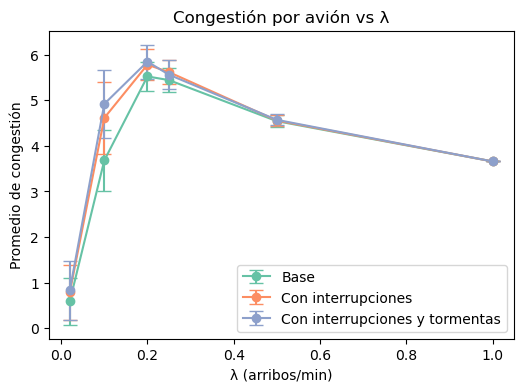

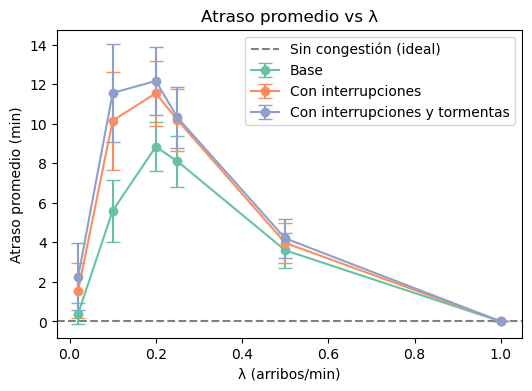

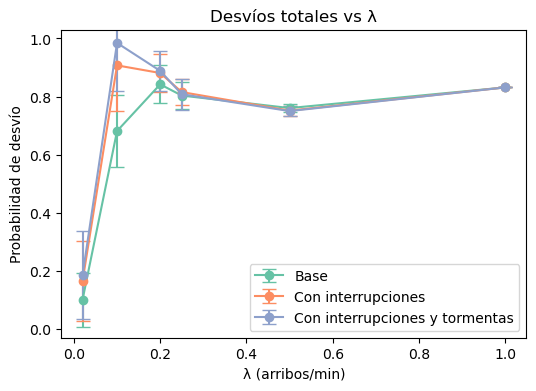

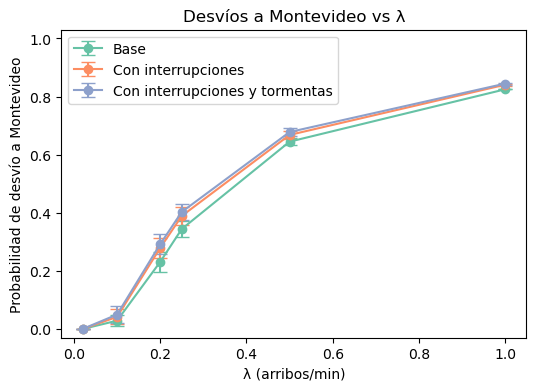

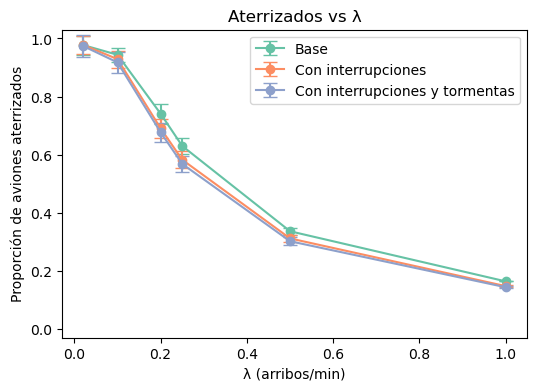

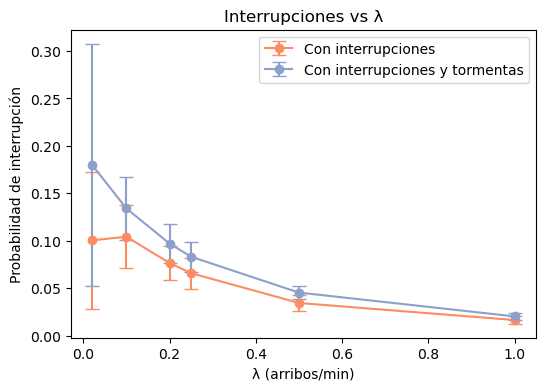

In [ ]:
datasets = [res_base, res_con_interrupciones, res_con_interrup_y_tormentas]
labels = ["Base", "Con interrupciones", "Con interrupciones y tormentas"]
analisisGraficos(datasets, labels=labels)

1. Congestión:

- La congestión aumenta con λ en los tres escenarios, pero se observa un patrón claro de deterioro progresivo.
- Escenario base: la congestión crece con λ y a partir de cierto nivel, empieza a bajar. Esto no significa que el aeropuerto “mejore”, sino que un número creciente de aviones son desviados directamente
- Interrupciones: la congestión es mayor que en el escenario base, especialmente para λ intermedios, debido a que los aviones deben retrasar sus aproximaciones.
- Interrupciones + tormentas: alcanza los valores más altos, reflejando el efecto combinado de eventos que limitan la capacidad de aterrizaje. Para λ altos, se reduce ligeramente por los desvíos masivos.

2. Atraso promedio:

- Escenario base: aumenta para λ intermedios y disminuye para λ altos porque los aviones desviados no se incluyen en el promedio.  
- Interrupciones: los atrasos son mayores que en el escenario base para todos los valores de λ, especialmente λ intermedios.  
- Interrupciones + tormentas: los atrasos superan los escenarios anteriores para λ bajos e intermedios, mostrando la mayor ineficiencia del sistema bajo condiciones críticas.

3. Desvíos totales:
- Escenario base: crecen rápidamente con λ, superando el 80% para λ altos.  
- Interrupciones: la proporción de desvíos aumenta respecto al base, actuando como un mecanismo de “escape” ante interrupciones, sobre todo para λ intermedios.
- Interrupciones + tormentas: los desvíos se incrementan aún más, reflejando la incapacidad del aeropuerto para atender la demanda en condiciones adversas.

4. Desvíos a Montevideo:
- Escenario base: la fracción que se va a Montevideo aumenta con λ.
- Interrupciones: aumenta respecto al escenario base, especialmente para λ intermedios.  
- Interrupciones + tormentas: la fracción que termina en Montevideo crece fuertemente, llegando a más del 80% para λ = 1, destacando el efecto crítico de tormentas combinadas con interrupciones.

5. Aterrizados:
- Escenario base: la mayoría aterriza para λ bajos, aunque disminuye drásticamente para λ ≥ 0.1.  
- Interrupciones: se reducen los aterrizajes efectivos en todos los λ, reflejando el impacto adicional de las interrupciones.  
- Interrupciones + tormentas: los aterrizajes caen aún más rápido, siendo menores al 20% para λ = 1, mostrando el colapso del aeropuerto.

6. Interrupciones:
- Escenario base: no aplicable (no hay interrupciones).
- Interrupciones: afectan entre 5% y 10% de los aviones para λ intermedios.  
- Interrupciones + tormentas: afectan entre 7% y 15% de los aviones, con un impacto mayor cuando se combinan con tormentas, amplificando los atrasos y desvíos.

Comparando los escenarios, se observa que cada factor externo empeora el desempeño progresivamente: primero las interrupciones aumentan congestión, atrasos y desvíos, y luego la combinación con tormentas genera la condición más crítica, con alta congestión, atrasos prolongados, desvíos masivos y baja proporción de aterrizajes efectivos. Esta comparación permite identificar los límites operativos del aeropuerto bajo distintas condiciones de demanda y perturbaciones.

---

### Ejercicio 7

Teniendo en consideración un nivel de $\lambda = 15/60$ y velocidades mínimas y máximas ya dadas, propondremos políticas de vuelos con el fin de reducir atrasos y/o eliminar desvíos a Montevideo en AEP.

#### Política 1: Reducción de velocidad al mínimo permitido en congestión

La idea central de esta política es gestionar la congestión dentro del área de control de manera proactiva:  

- Cuando se detecta que un avión se acerca demasiado al avión de adelante, es decir a menos de 4 minutos (indicando congestión), se reduce su velocidad al mínimo posible dentro del rango permitido, en lugar de simplemente disminuirla en 20 nudos como se hacía en la simulación base.  
- Esta reducción de velocidad busca mantener la separación mínima segura entre aviones, evitando que tengan que desviarse innecesariamente hacia Montevideo.
- Como algunos aviones podrían no lograr mantener la separación mínima incluso con la velocidad reducida, se implementa una verificación adicional: si la distancia es menor a 2 minutos, el avión se desvía para esperar más atrás en la cola, asegurando la seguridad.

In [ ]:
def monte_carlo_politica_1(lam, graficar, t_total_min=t_total_min):
    '''
    Simulación Monte Carlo de arribos y gestión de aviones en el aeropuerto (AEP)
    usando Política 1: reducción de velocidad al mínimo en congestión.
    '''

    # Generar aviones y arribos
    arribos = generar_arribos(t_total_min, lam)
    aviones = [Avion(t, i) for i, t in enumerate(arribos)]
    aviones.sort(key=lambda x: x.t_llegada)
    
    # Cola de aviones dentro de 100mn
    cola = list()
    
    # Variables para estadísticas
    cant_aviones = len(aviones)
    cant_congestion = 0     # número de veces que hubo congestión
    atrasos_totales = []    # lista de atrasos individuales
    cant_desvio = 0         # cantidad de aviones desviados
    cant_montevideo = 0     # cantidad de aviones desviados hacia montevideo
    cant_aterrizajes = 0    # cantidad de aterrizajes realizados

    # DataFrame para almacenar posiciones minuto a minuto
    posiciones = pd.DataFrame(index=range(t_total_min), columns=range(cant_aviones))

    # DataFrame para almacenar las acciones minuto a minuto (para graficar después)
    acciones = pd.DataFrame("vuelo", index=range(t_total_min), columns=range(cant_aviones))

    # Tiempo del último aterrizaje
    t_ultimo_aterrizaje = None

    # Calcular tiempos de aterrizaje ideales
    for avion in aviones:
        avion.t_aterrizaje_ideal = calcular_t_ideal(avion)

    # Simulación minuto a minuto
    for t in range(t_total_min):

        for i, avion in enumerate(aviones):

            # Si el avión está en vuelo y ya llegó al área de control
            if avion.estado == 'en_vuelo' and avion.t_llegada <= t:
                # Si recién llega, se agrega a la cola
                if not avion.encolado:
                    cola.append(avion)
                    avion.encolado = True

                # Buscar si hay avión adelante
                avion_adelante = encontrar_avion_adelante(cola, avion)

                if (avion.velocidadReducida and estan_a_mas_de_cinco(avion, avion_adelante)) or (not avion.velocidadReducida and not estan_cerca(avion, avion_adelante)):
                    avion.velocidadReducida = False
                    avion.actualizar_velocidad()
                else:
                    # Ajuste de velocidad para evitar colisión
                    avion.setVelocidadMinima()
                    cant_congestion += 1
                    avion.velocidadReducida = True
                    # Si no puede mantener la separación --> se desvía
                    if estan_muy_cerca(avion, avion_adelante):
                        avion.estado = 'desviado'
                        cola.remove(avion)
                        avion.encolado = False
                        cant_desvio += 1
                        acciones.loc[t, i] = 'desvio'

                # Avanzar la posición y registrar
                avion.avanzar()
                posiciones.loc[t, i] = avion.distancia
            
            # Si el avión está desviado
            elif avion.estado == 'desviado':
                avion.velocidad = -200      # se aleja del aeropuerto a 200 nudos
                avion.avanzar()
                posiciones.loc[t, i] = avion.distancia

                # Si se fue a más de 100mn, se desvía a Montevideo
                if avion.distancia > 100:
                    avion.estado = 'montevideo'
                    avion.actualizar_velocidad()
                    cant_montevideo += 1
                    acciones.loc[t, i] = 'desvio_montevideo'
                else:
                    # Intentar reinsertarlo en la cola si hay espacio
                    posicion = getPosicionGap(avion, cola)
                    if (posicion is not None):
                        avion.estado = 'en_vuelo'
                        cola.insert(posicion, avion)
                        avion.encolado = True
                        avion.velocidad = 500
            
            # Si el avión está desviado hacia montevideo pero no superó las 100mn
            elif avion.estado == 'desviado_volando_montevideo':
                avion.velocidad = -200      # se aleja del aeropuerto a 200 nudos
                avion.avanzar()
                posiciones.loc[t, i] = avion.distancia

                # Si se fue a más de 100mn, se desvía a Montevideo
                if avion.distancia > 100:
                    avion.estado = 'montevideo'
                    avion.actualizar_velocidad()
                    cant_montevideo += 1
                    acciones.loc[t, i] = 'desvio_montevideo'

            # El avión llegó a AEP
            if avion.estado == 'aterrizado' and avion.t_aterrizaje is None:
                if (t_ultimo_aterrizaje != None) and (t - t_ultimo_aterrizaje < 4):
                    # Está muy cerca del anterior aterrizaje, entonces dá la vuelta
                    avion.estado = 'desviado'
                    cola.remove(avion)
                    avion.encolado = False
                    avion.velocidad = -200  # nudos
                    cant_desvio += 1
                    acciones.loc[t, i] = 'desvio'
                else:
                    # El avión finalmente aterrizó
                    cant_aterrizajes += 1
                    avion.t_aterrizaje = t
                    acciones.loc[t, i] = 'aterrizaje'
                    if(avion in cola):
                        cola.remove(avion)
                    # Calcular atraso respecto al aterrizaje ideal
                    avion.atraso = avion.t_aterrizaje - avion.t_aterrizaje_ideal

    # Guardar atrasos y calcular promedio
    atrasos_totales = [avion.atraso for avion in aviones if avion.estado == 'aterrizado']
    atraso_prom = np.mean(atrasos_totales)
    if atraso_prom < 0:
        atraso_prom = 0

    # Estadísticas y visualización
    if graficar != None:
        # Contar aviones en cada estado final de la simulación
        conteo_final = {'en_vuelo': 0, 'desviado': 0, 'aterrizado': 0, 'montevideo': 0, 'interrumpido': 0}
        for avion in aviones:
            conteo_final[avion.estado] += 1

        print("Cantidad de aviones por estado al final del día:")
        for estado, cantidad in conteo_final.items():
            print(f"{estado}: {cantidad}")
        print(f"Atraso promedio: {atraso_prom}")
        
        # Visualización según parámetro
        if(graficar == 'Animar'):
            # Gif animado de los aviones
            graficarAnimado(posiciones, acciones, False, 0)

    return cant_congestion/cant_aviones, atraso_prom, cant_desvio/cant_aviones, cant_montevideo/cant_aviones, cant_aviones, cant_aterrizajes/cant_aviones, 0

#### Política 2: Liberar aviones para aliviar congestión

La lógica detrás esta política es la siguiente:

- Cuando se detecta que un avión se encuentra en un área con demasiados aviones próximos (más de 4 aviones dentro de los próximos 10 minutos), se decide desviarlo directamente hacia Montevideo, liberándolo para aliviar espacio en la cola.  
- Esta acción preventiva permite que el resto de los aviones puedan aterrizar con menor atraso y evita que se genere congestión extrema en el área de control.  
- La política se puede aplicar de diferentes maneras según la posición del avión dentro del grupo: se puede liberar al avión que está primero, al último o a uno intermedio, ajustando así el tradeoff entre atrasos generales y cantidad de desvíos a Montevideo.

In [ ]:
cota_minutos_proximos = 10      # límite de minutos próximos considerados 
cota_aviones_proximos = 4       # límite de aviones dentro de los próximos minutos

Definimos funciones auxiliares necesarias:

In [ ]:
def cant_aviones_proximos_Nmin(cola, avion, n=10):
    # Devuelve la cantidad de aviones próximos al avión actual que estén a una distancia de n min
    cant_aviones_proximos = 0
    for i in range(0, len(cola)):
        if(cola[i].id == avion.id):
            # Ya llegué al avión, no verifico los que están detrás de él
            return cant_aviones_proximos
        else:
            # Verifico si se encuentra a menos de n min y lo agrego
            if estan_cerca_n_min(avion, cola[i], n):
                cant_aviones_proximos += 1

    return cant_aviones_proximos

def cant_aviones_anteriores_Nmin(cola, avion, n=10):
    # Devuelve la cantidad de aviones anteriores al avión actual que estén a una distancia de n min
    cant_aviones_anteriores = 0
    lo_encontre = False
    for i in range(0, len(cola)):
        if lo_encontre:
            # Verifico si se encuentra a menos de n min y lo agrego
            if estan_cerca_n_min(cola[i], avion, n):
                cant_aviones_anteriores += 1
        else:
            if(cola[i].id == avion.id):
                # Ya llegué al avión, ahora puedo verificar los posteriores
                lo_encontre = True
            
    return cant_aviones_anteriores


def cant_aviones_entremedio_Nmin(cola, avion, n=10):
    # Devuelve la cantidad de aviones anteriores y posteriores del avión actual en un rango de n/2 min a cada lado
    anteriores = cant_aviones_anteriores_Nmin(cola, avion, n/2)
    posteriores = cant_aviones_proximos_Nmin(cola, avion, n/2)
    return anteriores + posteriores


def excesiva_congestion(politica, cola, avion):
    # Determina si un avión se encuentra en una situación de congestión excesiva
    # según la política seleccionada y la cantidad de aviones próximos en la cola
    if politica == 'liberar_ultimo':
        if cant_aviones_proximos_Nmin(cola, avion, cota_minutos_proximos) >= cota_aviones_proximos:
            return True
        else:
            return False
    elif politica == 'liberar_intermedio':
        if cant_aviones_entremedio_Nmin(cola, avion, cota_minutos_proximos) >= cota_aviones_proximos:
            return True
        else:
            return False
    elif politica == 'liberar_primero':
        if cant_aviones_anteriores_Nmin(cola, avion, cota_minutos_proximos) >= cota_aviones_proximos:
            return True
        else:
            return False

In [ ]:
def monte_carlo_politica_2(lam, graficar, politica, t_total_min=t_total_min):
    """
    Simulación Monte Carlo de arribos y gestión de aviones en AEP.
    Se aplica la Política 2: desviar aviones a Montevideo cuando hay excesiva congestión
    según la política seleccionada (liberar_ultimo, liberar_intermedio o liberar_primero).
    """

    # Generar aviones y arribos
    arribos = generar_arribos(t_total_min, lam)
    aviones = [Avion(t, i) for i, t in enumerate(arribos)]
    aviones.sort(key=lambda x: x.t_llegada)
    
    # Cola de aviones dentro de 100mn
    cola = list()
    
    # Variables para estadísticas
    cant_aviones = len(aviones)
    cant_congestion = 0     # número de veces que hubo congestión
    atrasos_totales = []    # lista de atrasos individuales
    cant_desvio = 0         # cantidad de aviones desviados
    cant_montevideo = 0     # cantidad de aviones desviados hacia montevideo
    cant_aterrizajes = 0    # cantidad de aterrizajes realizados

    # DataFrame para almacenar posiciones minuto a minuto
    posiciones = pd.DataFrame(index=range(t_total_min), columns=range(cant_aviones))

    # DataFrame para almacenar las acciones minuto a minuto (para graficar después)
    acciones = pd.DataFrame("vuelo", index=range(t_total_min), columns=range(cant_aviones))

    # Tiempo del último aterrizaje
    t_ultimo_aterrizaje = None

    # Calcular tiempos de aterrizaje ideales
    for avion in aviones:
        avion.t_aterrizaje_ideal = calcular_t_ideal(avion)

    # Simulación minuto a minuto
    for t in range(t_total_min):

        for i, avion in enumerate(aviones):

            # Si el avión está en vuelo y ya llegó al área de control
            if avion.estado == 'en_vuelo' and avion.t_llegada <= t:
                # Si recién llega, se agrega a la cola
                if not avion.encolado:
                    cola.append(avion)
                    avion.encolado = True

                # Buscar si hay avión adelante
                avion_adelante = encontrar_avion_adelante(cola, avion)

                if (avion.velocidadReducida and estan_a_mas_de_cinco(avion, avion_adelante)) or (not avion.velocidadReducida and not estan_cerca(avion, avion_adelante)):
                    avion.velocidadReducida = False
                    avion.actualizar_velocidad()
                else:
                    # Ajuste de velocidad para evitar colisión
                    avion.velocidad = avion_adelante.velocidad - 20
                    cant_congestion += 1
                    avion.velocidadReducida = True
                    # Si no puede mantener la separación --> se desvía
                    if avion.verificar_desvio():
                        avion.estado = 'desviado'
                        cola.remove(avion)
                        avion.encolado = False
                        cant_desvio += 1
                        acciones.loc[t, i] = 'desvio'

                # Avanzar la posición y registrar
                avion.avanzar()
                posiciones.loc[t, i] = avion.distancia

                # Si en los próximos cota_minutos_proximos hay más de cota_aviones_proximos aviones me desvío a montevideo
                if avion.estado != 'desviado' and politica != None and excesiva_congestion(politica, cola, avion):
                    avion.estado = 'desviado_volando_montevideo'
                    cola.remove(avion)
                    avion.encolado = False
                    cant_desvio += 1
                    acciones.loc[t, i] = 'desvio_montevideo'
            
            # Si el avión está desviado
            elif avion.estado == 'desviado':
                avion.velocidad = -200      # se aleja del aeropuerto a 200 nudos
                avion.avanzar()
                posiciones.loc[t, i] = avion.distancia

                # Si se fue a más de 100mn, se desvía a Montevideo
                if avion.distancia > 100:
                    avion.estado = 'montevideo'
                    avion.actualizar_velocidad()
                    cant_montevideo += 1
                    acciones.loc[t, i] = 'desvio_montevideo'
                else:
                    # Intentar reinsertarlo en la cola si hay espacio
                    posicion = getPosicionGap(avion, cola)
                    if (posicion is not None):
                        avion.estado = 'en_vuelo'
                        cola.insert(posicion, avion)
                        avion.encolado = True
                        avion.velocidad = 500
            
            # Si el avión está desviado hacia montevideo pero no superó las 100mn
            elif avion.estado == 'desviado_volando_montevideo':
                avion.velocidad = -200      # se aleja del aeropuerto a 200 nudos
                avion.avanzar()
                posiciones.loc[t, i] = avion.distancia

                # Si se fue a más de 100mn, se desvía a Montevideo
                if avion.distancia > 100:
                    avion.estado = 'montevideo'
                    avion.actualizar_velocidad()
                    cant_montevideo += 1
                    acciones.loc[t, i] = 'desvio_montevideo'

            # El avión llegó a AEP
            if avion.estado == 'aterrizado' and avion.t_aterrizaje is None:
                if (t_ultimo_aterrizaje != None) and (t - t_ultimo_aterrizaje < 4):
                    # Está muy cerca del anterior aterrizaje, entonces dá la vuelta
                    avion.estado = 'desviado'
                    cola.remove(avion)
                    avion.encolado = False
                    avion.velocidad = -200  # nudos
                    cant_desvio += 1
                    acciones.loc[t, i] = 'desvio'
                else:
                    # El avión finalmente aterrizó
                    cant_aterrizajes += 1
                    avion.t_aterrizaje = t
                    acciones.loc[t, i] = 'aterrizaje'
                    if(avion in cola):
                        cola.remove(avion)
                    # Calcular atraso respecto al aterrizaje ideal
                    avion.atraso = avion.t_aterrizaje - avion.t_aterrizaje_ideal

    # Guardar atrasos y calcular promedio
    atrasos_totales = [avion.atraso for avion in aviones if avion.estado == 'aterrizado']
    atraso_prom = np.mean(atrasos_totales)
    if atraso_prom < 0:
        atraso_prom = 0

    # Estadísticas y visualización
    if graficar != None:
        # Contar aviones en cada estado final de la simulación
        conteo_final = {'en_vuelo': 0, 'desviado': 0, 'aterrizado': 0, 'montevideo': 0, 'interrumpido': 0}
        for avion in aviones:
            conteo_final[avion.estado] += 1

        print("Cantidad de aviones por estado al final del día:")
        for estado, cantidad in conteo_final.items():
            print(f"{estado}: {cantidad}")
        print(f"Atraso promedio: {atraso_prom}")
        
        # Visualización según parámetro
        if(graficar == 'Animar'):
            # Gif animado de los aviones
            graficarAnimado(posiciones, acciones, False, 0)

    return cant_congestion/cant_aviones, atraso_prom, cant_desvio/cant_aviones, cant_montevideo/cant_aviones, cant_aviones, cant_aterrizajes/cant_aviones, 0

#### Comparación entre políticas y caso base

Para comparar las políticas y el caso base, generamos simulaciones para cada caso y visualizamos las diferencias.

In [ ]:
def simulacion_lambdas_politicas(n_sim, politica):
    """
    Simulación Monte Carlo de arribos y gestión de aviones en el aeropuerto (AEP) para distintos lambdas con varias iteraciones y utilizando politicas
    Parámetros:
        n_sim: cantidad de días que se simula por cada lambda
        politica: politica1, liberar_ultimo, liberar_intermedio o liberar_primero
    Retorna:
        df: un dataframe con métricas de la simulación
    """

    lambdas = [0.02, 0.1, 0.2, 0.25, 0.5, 1] # tasas de arribo a evaluar

    resultados = []   # guardamos estadísticas finales

    for lam in lambdas:
        # Listas para acumular resultados de las simulaciones
        promedio_congestiones = []
        atrasos = []
        promedio_desvios = []
        promedio_desvios_montevideo = []
        cant_aviones_ls = []
        promedio_aterrizados_ls = []

        # Repetimos Monte Carlo n_sim veces para cada λ
        for _ in range(n_sim):
            prom_congest, atraso, prom_desvio, prom_montevideo, cant_aviones, prom_aterrizados, _ = monte_carlo_politica_2(lam, None, politica) if politica != 'politica1' else monte_carlo_politica_1(lam, None)

            # Guardamos los resultados de esta corrida
            promedio_congestiones.append(prom_congest)
            atrasos.append(atraso)
            promedio_desvios.append(prom_desvio)
            promedio_desvios_montevideo.append(prom_montevideo)
            cant_aviones_ls.append(cant_aviones)
            promedio_aterrizados_ls.append(prom_aterrizados)
        
        # Estadísticas: media y desvío de cada métrica
        mean_congest = np.mean(promedio_congestiones)
        error_congest = np.std(promedio_congestiones)

        atraso_prom = np.mean(atrasos)
        error_atraso = np.std(atrasos)

        mean_desvio = np.mean(promedio_desvios)
        error_desvio = np.std(promedio_desvios)

        mean_desvio_montevideo = np.mean(promedio_desvios_montevideo)
        error_desvio_montevideo = np.std(promedio_desvios_montevideo)

        mean_cant_aviones = np.mean(cant_aviones_ls)
        error_cant_aviones = np.std(cant_aviones_ls)

        mean_aterrizados = np.mean(promedio_aterrizados_ls)
        error_aterrizados = np.std(promedio_aterrizados_ls)

        # Guardamos resultados en la tabla
        resultados.append({
            'lambda': lam,
            'mean_aviones': mean_cant_aviones,
            'error_aviones': error_cant_aviones,
            'mean_congest': mean_congest,
            'error_congest': error_congest,
            'atraso_prom': atraso_prom,
            'error_atraso': error_atraso,
            'mean_desvio': mean_desvio,
            'error_desvio': error_desvio,
            'mean_desvio_montevideo': mean_desvio_montevideo,
            'error_desvio_montevideo': error_desvio_montevideo,
            'mean_aterrizados': mean_aterrizados,
            'error_aterrizados': error_aterrizados
        })

    # Convertimos la lista de resultados en un DataFrame para analizar
    return pd.DataFrame(resultados)

Usamos nuevamente una cantidad de simulaciones de 200. Misma cantidad para todas para que la comparación sea justa.

In [ ]:
N_SIM_VALUE=200

Simulación de la política 1:

In [ ]:
np.random.seed(SEED)
res_politica1 = simulacion_lambdas_politicas(N_SIM_VALUE, "politica1")

Simulación de la política 2, liberando al último avión:

Esta variante toma a cada avión y verifica la cantidad de aviones en los próximos minutos.

In [ ]:
np.random.seed(SEED)
res_politica2_liberar_ultimo = simulacion_lambdas_politicas(N_SIM_VALUE, "liberar_ultimo")

Simulación de la política 2 , liberando al avión intermedio:

Esta variante toma a cada avión y verifica la cantidad de aviones antes y después del avión (repartiendo el rango a la mitad en cada lado).

In [ ]:
np.random.seed(SEED)
res_politica2_liberar_intermedio = simulacion_lambdas_politicas(N_SIM_VALUE, "liberar_intermedio")

Simulación de la política 2, liberando al primer avión:

Esta variante toma a cada avión y verifica la cantidad de aviones en los anteriores minutos.

In [ ]:
np.random.seed(SEED)
res_politica2_liberar_primero = simulacion_lambdas_politicas(N_SIM_VALUE, "liberar_primero")

Generamos gráficos para poder comparar estos modelos:

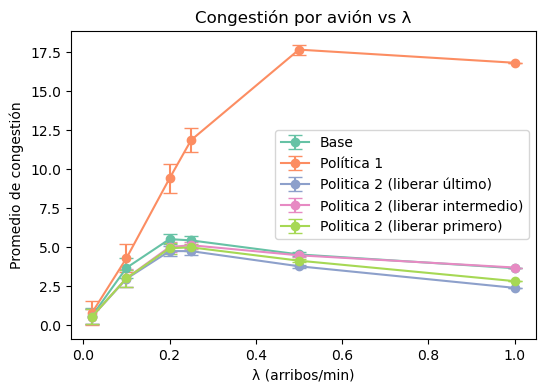

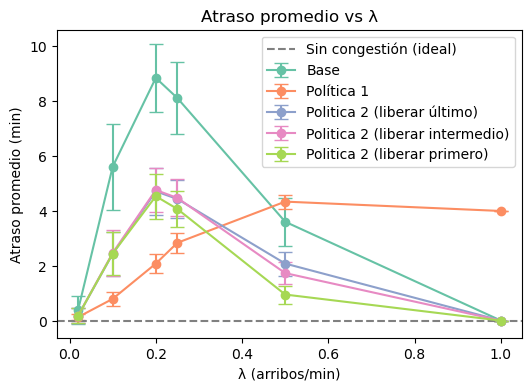

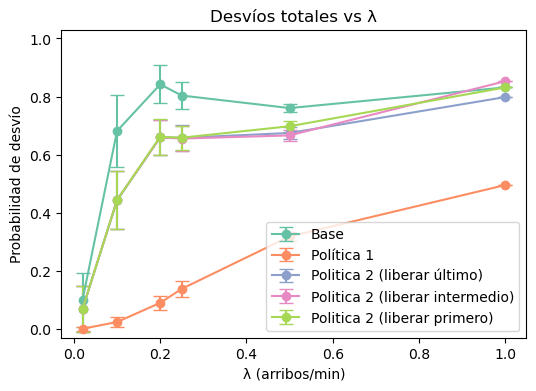

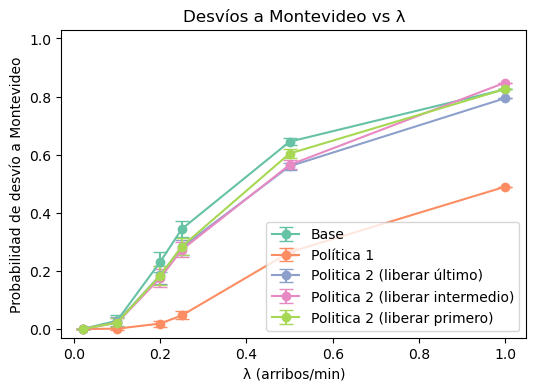

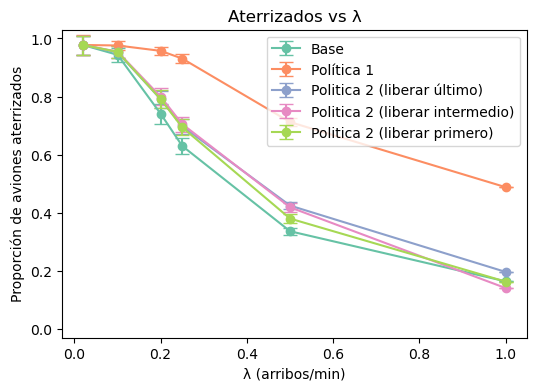

<Figure size 600x400 with 0 Axes>

In [ ]:
datasets = [res_base, res_politica1, res_politica2_liberar_ultimo, res_politica2_liberar_intermedio, res_politica2_liberar_primero]
labels = ["Base", "Política 1", "Politica 2 (liberar último)", "Politica 2 (liberar intermedio)", "Politica 2 (liberar primero)"]
analisisGraficos(datasets, labels=labels)

1. Congestión:

- El escenario base y las políticas 2 muestran una congestión moderada que aumenta hasta $\lambda \approx 0.2$ y luego baja.
- En cambio, la política 1 muestra congestión muy alta, dado que retiene aviones en la cola (a velocidad mínima), acumulando muchos dentro del área. La política 2 alivia la cola desviando aviones.

2. Atraso promedio:

- Los atrasos crecen a medida que aumenta $\lambda$ hasta un pico $(\approx 0.2)$ y luego disminuyen cuando aumentan los desvíos a Montevideo.
- La política 1, en cambio, mantiene el aumento de atrasos en función de $\lambda$ ya que los desvíos a Montevideo no ocurren y se provocan más atrasos en AEP.
- Es notable una gran brecha entre el atraso promedio en el modelo base y las políticas 2, demostrando su eficiencia para mejorar el sistema.

3. Desvíos totales:

- Las políticas 2 generan mayor probabilidad de desvío $(\approx 70-80\%)$ en rangos altos de $\lambda$, mientras que la política 1 tiene desvíos mucho menores.
- Esto sucede porque las políticas 2 incluyen desvíos como mecanismo preventivo, mientras que la política 1 intenta conservar los vuelos en el sistema y sólo desvía cuando es inevitable.

4. Desvíos a Montevideo:

- Sigue la misma tendencia que los desvíos totales: alto en políticas 2 y bajo en política 1.
- Las variantes de la política 2 expulsan aviones que luego terminan en Montevideo, mientras que la política 1 evita esos desvíos reteniendo aviones.

5. Proporción de aterrizados:

- La política 1 mantiene mayor proporción de aterrizajes, mientras que las políticas 2 reducen fuertemente la fracción que aterriza.
- Esto se explica ya que la política 1 prioriza conservar vuelos en la cola hasta que aterricen, mientras que las políticas 2 sacrifican vuelos (los desvían) para liberar capacidad.

De este análisis, se desprende que cada política prioriza un aspecto distinto del sistema, lo que genera trade-offs claros entre congestión, atrasos, desvíos y aterrizajes. 

La política 1 se caracteriza por minimizar los desvíos y sostener una mayor proporción de aterrizajes en AEP, pero lo hace a costa de acumular una congestión muy elevada y provocar atrasos considerables, dado que mantiene los aviones en espera dentro del área de control.

En contraste, la política 2, en todas sus variantes, alivia la congestión y reduce los atrasos promedio, especialmente en escenarios de alta demanda, pero lo logran desviando un alto porcentaje de vuelos, lo que reduce notablemente la cantidad de aviones que efectivamente aterrizan en AEP.

El escenario base, por su parte, se ubica en una situación intermedia, sin ventajas claras respecto de las políticas diseñadas.

En definitiva, la elección de la política depende de la prioridad estratégica:

- Si lo central es maximizar los aterrizajes en AEP y evitar desvíos, conviene aplica la política 1 aún aceptando demoras y congestión.
- En cambio, si lo prioritario es reducir la congestión y mejorar la fluidez operativa, la política 2 resulta más adecuada, aún cuando implique un mayor número de desvíos.

---

### Conclusiones generales

La simulación del proceso de arribos en Aeroparque utilizando un enfoque basado en simulación Monte Carlo y un proceso de Poisson permitió comprender como eventos externos, la demanda y posibles políticas de operación pueden generar un impacto en métricas relevantes como aterrizajes y desvíos. 

Gracias a este enfoque, pudimos comparar un escenario base del aeropuerto con casos más adversos (presentando interrupciones y tormentas) y comprobar cómo estos eventos pueden agravar la congestión, los atrasos y los desvíos.

Los resultados mostraron que el sistema presenta un claro trade-off entre atrasos y desvíos: a tasas de arribo bajas (λ pequeños), el aeropuerto funciona de manera estable y casi todos los vuelos aterrizan sin mayores inconvenientes; en tasas intermedias, comienzan a observarse mayores atrasos y desvíos que evidencian la vulnerabilidad del sistema; y en tasas altas, la saturación provoca que la mayoría de los vuelos deba desviarse, reduciendo artificialmente el atraso promedio pero incrementando fuertemente la ineficiencia.

Las políticas evaluadas reforzaron la utilidad del modelo para diseñar mejoras y refuerzan el trade-off entre atrasos y desvíos. La política 1, incrementó la congestión promedio por avión y el atraso en λ grandes, pero generó beneficios como la baja de desvíos a Montevideo y el aumento de la taza de aterrizajes. En cambio, la política 2 mostró mejor desempeño en cuanto a la congestión y atrasos para λ mayores.

En síntesis, el trabajo evidenció que la capacidad del aeropuerto es altamente sensible a la tasa de arribos y a la presencia de eventos imprevistos. El uso de simulación de Monte Carlo resultó fundamental para capturar estas dinámicas y poder evaluar futuras políticas operativas, mostrando que ajustes relativamente simples en la gestión de aproximaciones pueden traducirse en mejoras sustanciales en el desempeño.